# 🌳 Decision Tree Classifier - A Visual Guide with Code
_[Adapted from Towards Data Science](https://towardsdatascience.com/decision-tree-classifier-explained-a-visual-guide-with-code-examples-for-beginners-7c863f06a71e/)_

## What is a Decision Tree?

A decision tree is a supervised learning algorithm used for both classification and regression tasks.

It works by breaking down a dataset into smaller subsets while simultaneously developing an associated tree structure.

## How a Tree Learns

- The tree splits nodes based on the feature that results in the highest information gain
- It continues splitting until it hits a stopping criterion (like maximum depth or minimum samples per leaf)

## Splitting Criteria

**Gini Impurity:**  
$$G = 1 - \sum_{i=1}^C p_i^2$$

**Entropy:**  
$$E = - \sum_{i=1}^C p_i \log_2(p_i)$$

Most decision trees use Gini by default, but entropy is also common.

For demonstration, we shall use `scikit-learn`'s toy Diabets diabetes to drive our point home. In this demo, we use decision tree  classifiers to 

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import tree

# Load and split the diabetes dataset

diabetes = load_diabetes()
cat_target = diabetes.target.copy()
diabetes.target[cat_target < 140] = 0
diabetes.target[cat_target >= 140] = 1
diabetes.target_names = ['High Risk', 'Low Risk']
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.3, random_state=42)


In [15]:

# Build the classifier
clf_diabetes = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10, max_features="log2", random_state=42, min_samples_leaf=3)
clf_diabetes.fit(X_train, y_train)

# Print the classifier
print(clf_diabetes)

DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features='log2',
                       min_samples_leaf=3, min_samples_split=10,
                       random_state=42)


In [16]:
import matplotlib.pyplot as plt
plt.ioff()
plt.figure(figsize=(50, 40))
tree.plot_tree(clf_diabetes, filled=True, feature_names=diabetes.feature_names, class_names=diabetes.target_names, impurity=True)
plt.title("Decision Tree for Diabetes Dataset")


Text(0.5, 1.0, 'Decision Tree for Diabetes Dataset')

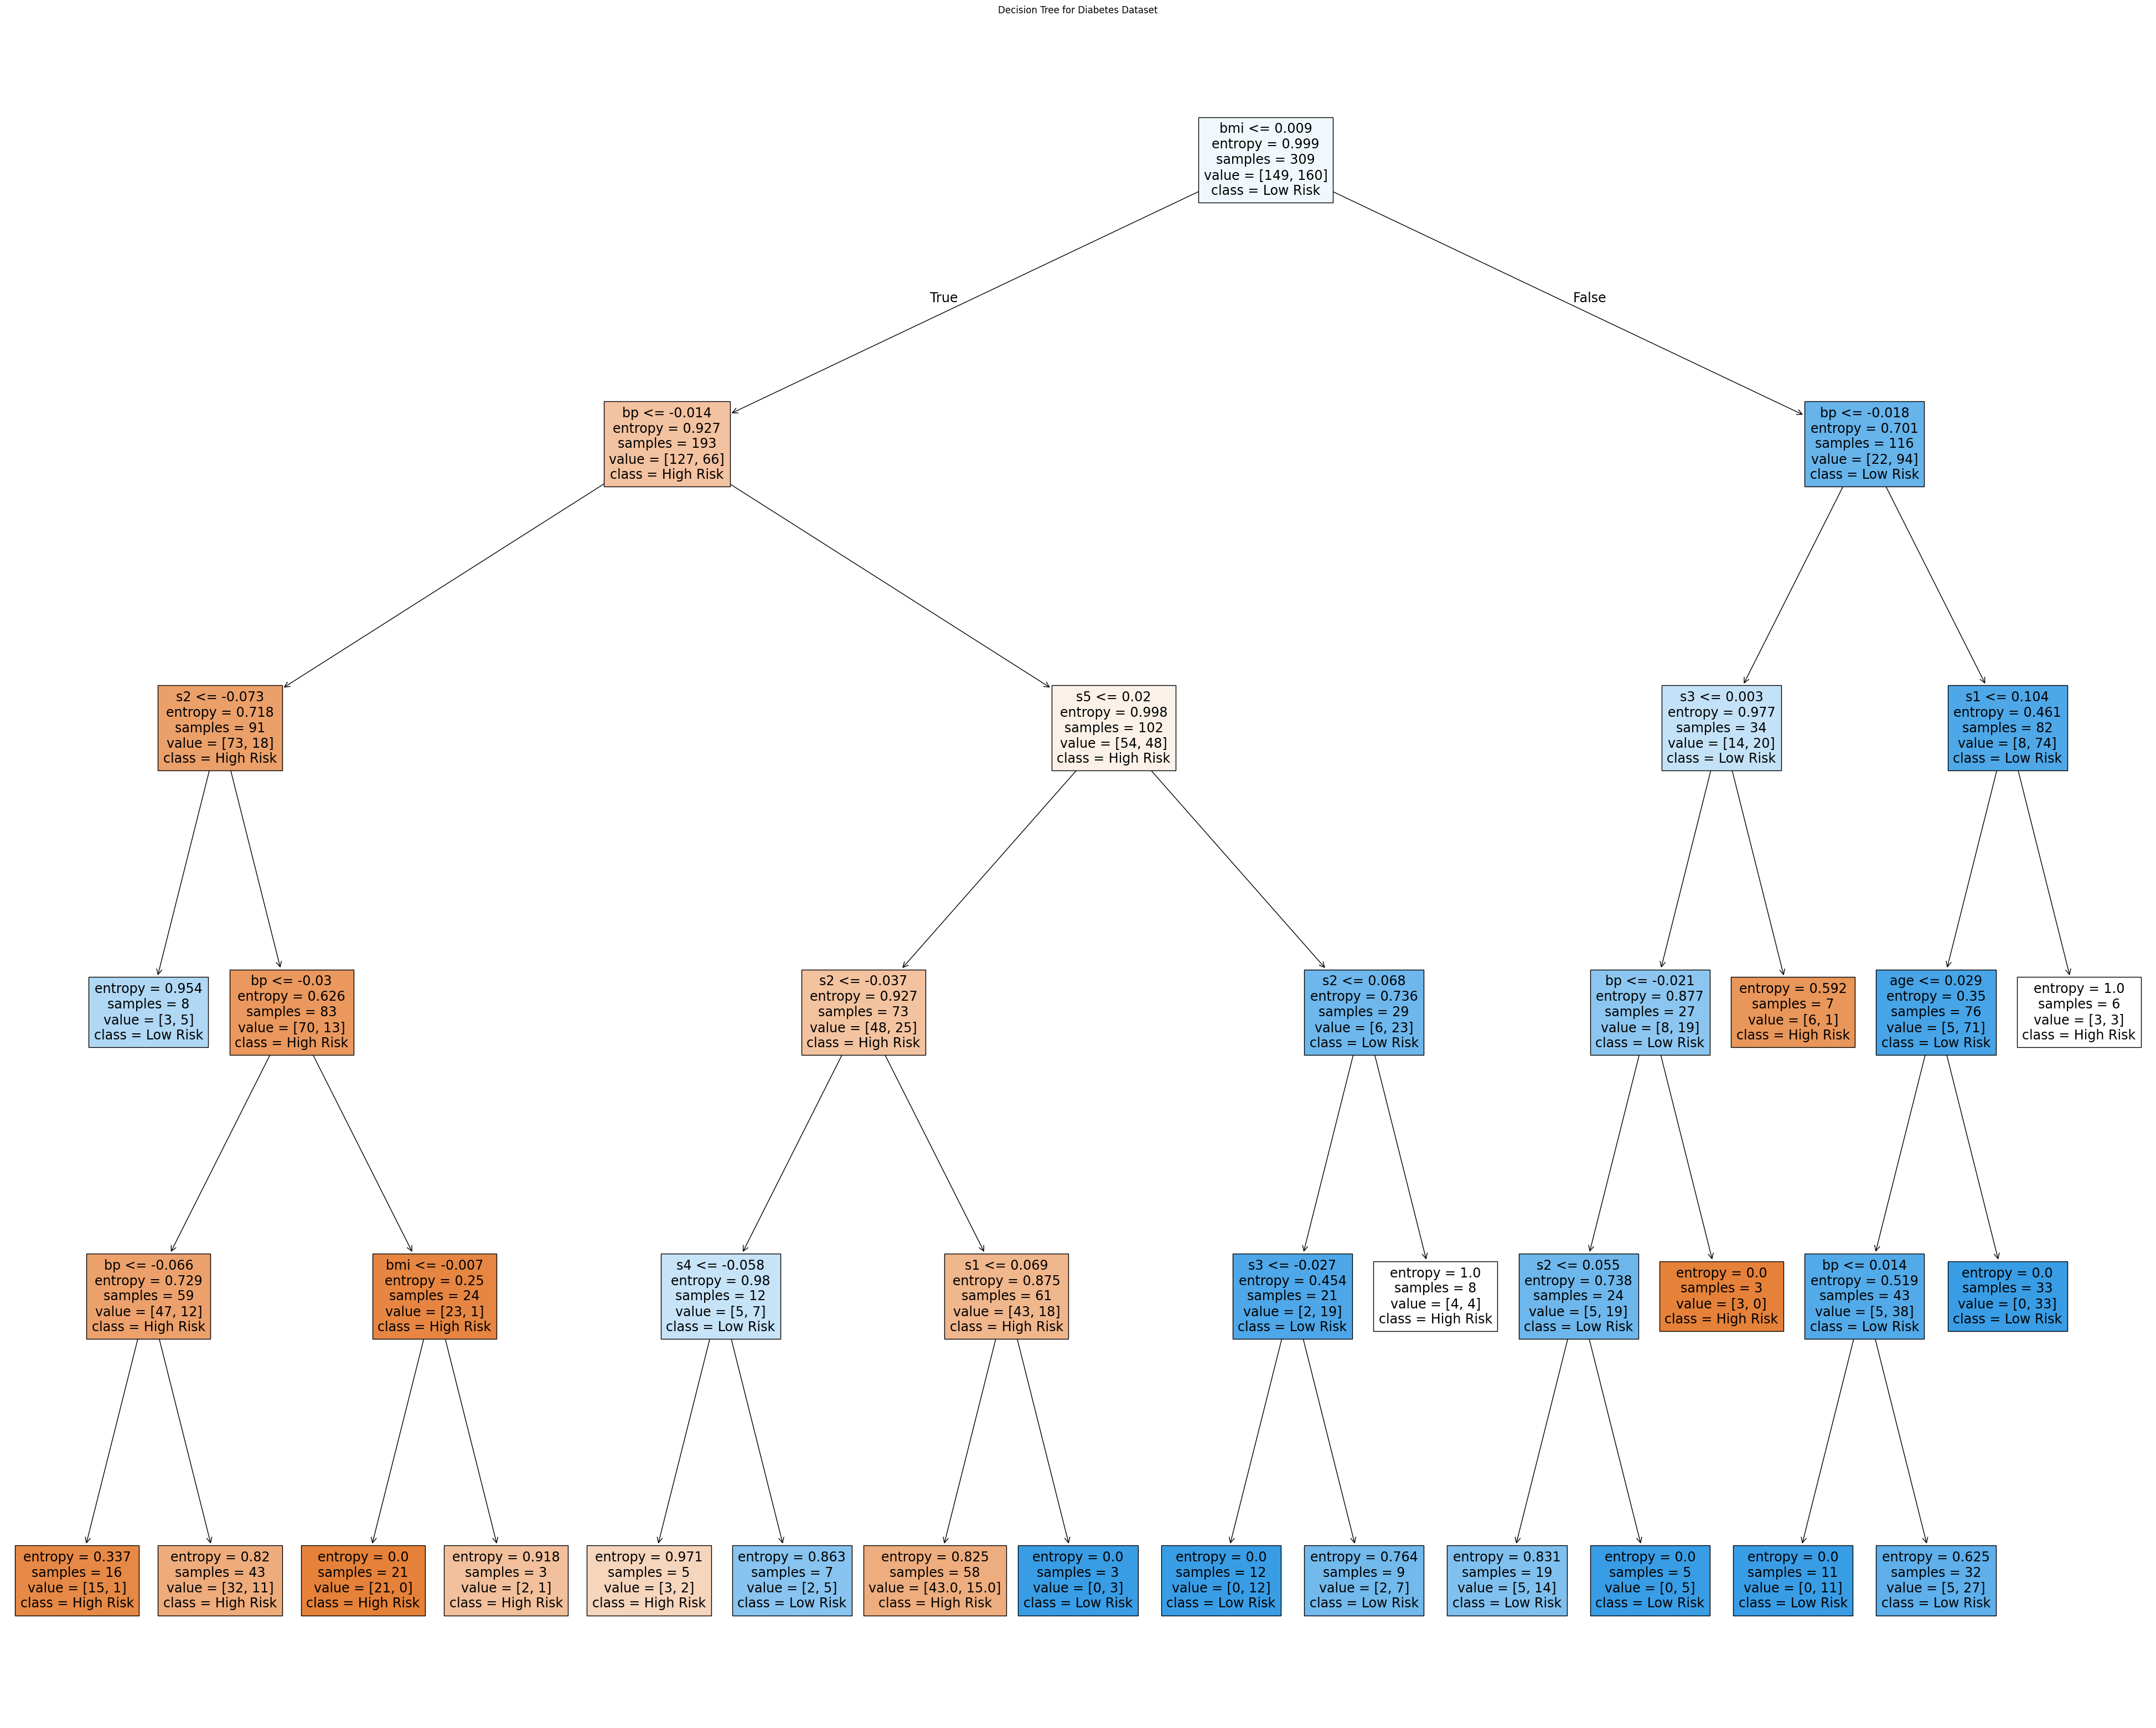

In [17]:

plt.show()

In [18]:
from sklearn.metrics import accuracy_score

y_pred = clf_diabetes.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.68


Decision trees provides explainability of our predictions

In [19]:
import numpy as np


importances = clf_diabetes.feature_importances_
indices = np.argsort(importances)
plt.ioff()
# Plot the feature importance chart as a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], align="center")
plt.yticks(range(len(importances)), np.array(diabetes.feature_names)[indices])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.tight_layout()


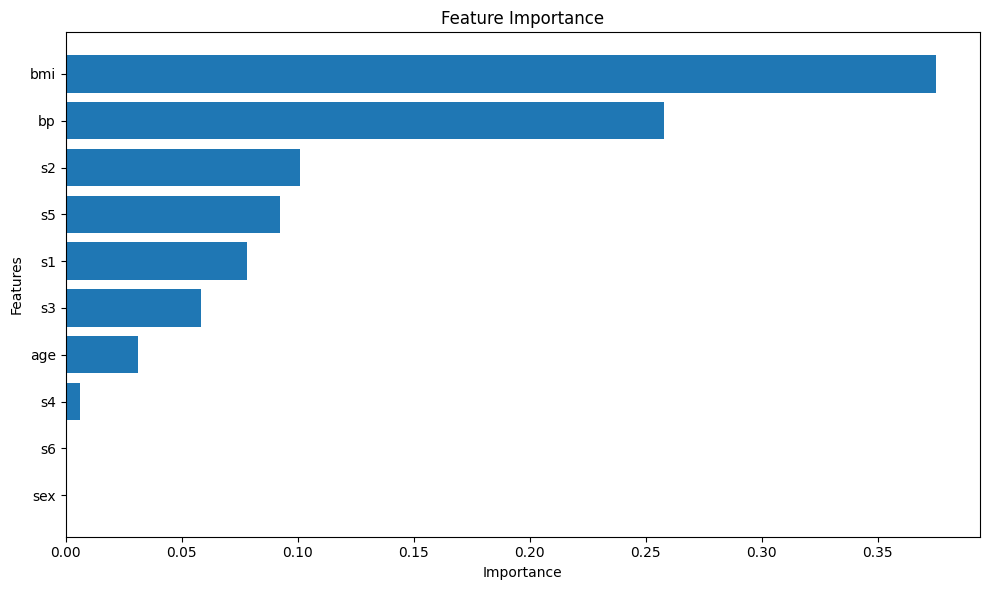

: 

In [ ]:
plt.show()

### ✅ Pros:
- Easy to interpret
- Handles both numerical and categorical data
- No need for feature scaling

### ❌ Cons:
- Can overfit if not pruned
- Sensitive to data changes
- Can be biased toward features with more levels

### References

- [Decision Tree Classifier Visual Guide (TDS)](https://towardsdatascience.com/decision-tree-classifier-explained-a-visual-guide-with-code-examples-for-beginners-7c863f06a71e)
- Scikit-learn Documentation
